# Notebook 01 — Explore LIF Neuron Dynamics

Goals:
1. Instantiate a single LIFLayer and drive it with a constant current.
2. Visualise the membrane voltage and spike output.
3. Sweep the threshold parameter and plot firing rate vs. input current (f–I curve).
4. Check that Norse state dimensions are correct before wiring into a full network.

In [11]:
import sys
sys.path.insert(0, '..')  # make project root importable

import torch
import matplotlib.pyplot as plt

from neuron_models import LIFLayer
from visualization import raster_plot, firing_rate_heatmap


In [12]:
# ── Parameters ────────────────────────────────────────────────────────────────
T        = 500   # timesteps
batch    = 4
n_in     = 64
n_hidden = 128
dt       = 1.0   # ms

layer = LIFLayer(input_size=n_in, hidden_size=n_hidden, dt=dt)
print(layer)

LIFLayer(
  (input_weights): Linear(in_features=64, out_features=128, bias=False)
  (recurrent_weights): Linear(in_features=128, out_features=128, bias=False)
  (lif): LIFCell(p=LIFParameters(tau_syn_inv=tensor(200.), tau_mem_inv=tensor(100.), v_leak=tensor(0.), v_th=tensor(1.), v_reset=tensor(0.), method='super', alpha=tensor(100.)), dt=1.0)
)


In [8]:
# ── Drive with Poisson input ───────────────────────────────────────────────────
rate = 0.05  # spike probability per timestep
input_seq = (torch.rand(T, batch, n_in) < rate).float()

with torch.no_grad():
    spike_train, states = layer.simulate(input_seq)

print("Spike train shape:", spike_train.shape)  # (T, batch, n_hidden)
print("Mean firing rate: {:.2f} Hz".format(spike_train.mean().item() / (dt * 1e-3)))

Spike train shape: torch.Size([500, 4, 128])
Mean firing rate: 17.95 Hz


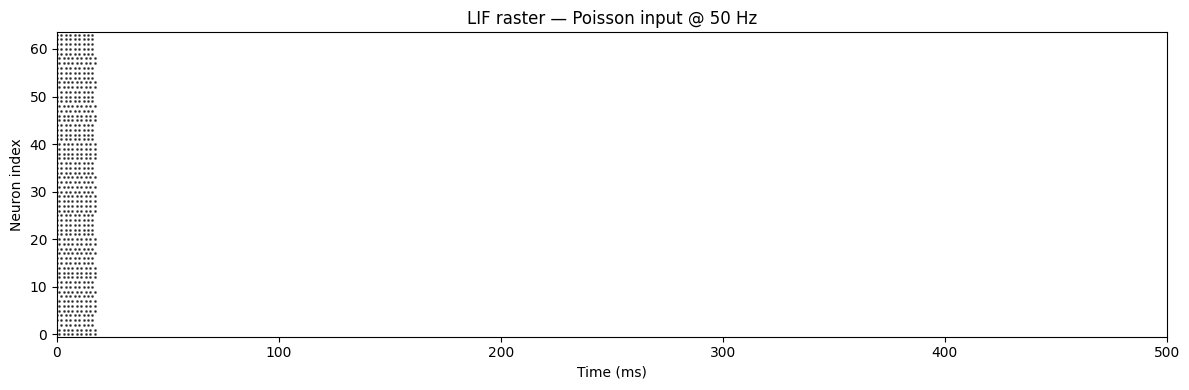

In [9]:
# ── Raster plot for the first batch element ───────────────────────────────────
fig = raster_plot(spike_train[:, 0, :], dt=dt, neuron_subset=64,
                  title="LIF raster — Poisson input @ 50 Hz")
plt.show()

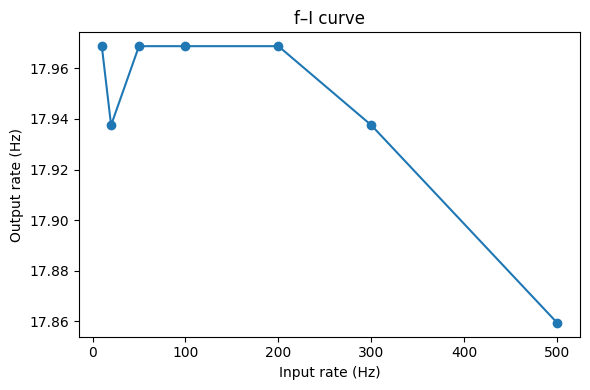

In [10]:
# ── f-I curve: sweep input rates and measure output rate ────────────────────
input_rates = [0.01, 0.02, 0.05, 0.1, 0.2, 0.3, 0.5]
output_rates = []

for r in input_rates:
    x = (torch.rand(T, 1, n_in) < r).float()
    with torch.no_grad():
        spk, _ = layer.simulate(x)
    hz = spk.sum().item() / (n_hidden * T * dt * 1e-3)
    output_rates.append(hz)

plt.figure(figsize=(6, 4))
plt.plot([r / (dt * 1e-3) for r in input_rates], output_rates, 'o-')
plt.xlabel('Input rate (Hz)')
plt.ylabel('Output rate (Hz)')
plt.title('f–I curve')
plt.tight_layout()
plt.show()

In [14]:
rates = [0.01, 0.05, 0.1, 0.2, 0.5]

for r in rates:
    x = (torch.rand(T, 1, n_in) < r).float()

    with torch.no_grad():
        spk, _ = layer.simulate(x)

    firing_rate = spk.mean().item() / (dt * 1e-3)

    print(f"Input probability: {r:.2f} | Output firing rate: {firing_rate:.2f} Hz")

Input probability: 0.01 | Output firing rate: 17.94 Hz
Input probability: 0.05 | Output firing rate: 17.94 Hz
Input probability: 0.10 | Output firing rate: 17.97 Hz
Input probability: 0.20 | Output firing rate: 17.95 Hz
Input probability: 0.50 | Output firing rate: 17.73 Hz


In [15]:
print("Input weight mean:", layer.input_weights.weight.mean().item())
print("Input weight std :", layer.input_weights.weight.std().item())

print("Recurrent weight mean:", layer.recurrent_weights.weight.mean().item())
print("Recurrent weight std :", layer.recurrent_weights.weight.std().item())

Input weight mean: 0.00017089498578570783
Input weight std : 0.07216056436300278
Recurrent weight mean: 0.0005841301754117012
Recurrent weight std : 0.05084199830889702


In [16]:
# Temporarily disable recurrent connections
with torch.no_grad():
    layer.recurrent_weights.weight.zero_()

rates = [0.01, 0.05, 0.1, 0.2, 0.5]

for r in rates:
    x = (torch.rand(T, 1, n_in) < r).float()

    with torch.no_grad():
        spk, _ = layer.simulate(x)

    firing_rate = spk.mean().item() / (dt * 1e-3)

    print(f"Input probability: {r:.2f} | Output firing rate: {firing_rate:.2f} Hz")

Input probability: 0.01 | Output firing rate: 17.97 Hz
Input probability: 0.05 | Output firing rate: 17.95 Hz
Input probability: 0.10 | Output firing rate: 18.00 Hz
Input probability: 0.20 | Output firing rate: 17.97 Hz
Input probability: 0.50 | Output firing rate: 17.83 Hz


In [17]:
rates = [0.01, 0.05, 0.1, 0.2, 0.5]

for r in rates:
    x = (torch.rand(T, 1, n_in) < r).float()

    # amplify input current
    x = x * 10.0

    with torch.no_grad():
        spk, _ = layer.simulate(x)

    firing_rate = spk.mean().item() / (dt * 1e-3)

    print(f"Input probability: {r:.2f} | Output firing rate: {firing_rate:.2f} Hz")

Input probability: 0.01 | Output firing rate: 17.30 Hz
Input probability: 0.05 | Output firing rate: 17.37 Hz
Input probability: 0.10 | Output firing rate: 17.25 Hz
Input probability: 0.20 | Output firing rate: 17.17 Hz
Input probability: 0.50 | Output firing rate: 17.06 Hz


In [18]:
from norse.torch import LIFParameters
import torch

custom_params = LIFParameters(
    v_th=torch.as_tensor(0.2)  # much lower threshold
)

test_layer = LIFLayer(
    input_size=n_in,
    hidden_size=n_hidden,
    dt=dt,
    params=custom_params
)

rates = [0.01, 0.05, 0.1, 0.2, 0.5]

for r in rates:
    x = (torch.rand(T, 1, n_in) < r).float()

    with torch.no_grad():
        spk, _ = test_layer.simulate(x)

    firing_rate = spk.mean().item() / (dt * 1e-3)

    print(f"Input probability: {r:.2f} | Output firing rate: {firing_rate:.2f} Hz")

Input probability: 0.01 | Output firing rate: 18.00 Hz
Input probability: 0.05 | Output firing rate: 18.00 Hz
Input probability: 0.10 | Output firing rate: 18.00 Hz
Input probability: 0.20 | Output firing rate: 18.00 Hz
Input probability: 0.50 | Output firing rate: 17.95 Hz


In [19]:
x = (torch.rand(T, 1, n_in) < 0.2).float()

with torch.no_grad():
    spk, _ = test_layer.simulate(x)

print("Spike tensor min :", spk.min().item())
print("Spike tensor max :", spk.max().item())
print("Spike tensor mean:", spk.mean().item())

print("Total spikes:", spk.sum().item())
print("Tensor shape:", spk.shape)

Spike tensor min : 0.0
Spike tensor max : 1.0
Spike tensor mean: 0.017921874299645424
Total spikes: 1147.0
Tensor shape: torch.Size([500, 1, 128])


In [20]:
from norse.torch import LIFParameters

fast_params = LIFParameters(
    tau_mem_inv=torch.as_tensor(500.0),  # much faster membrane decay
    v_th=torch.as_tensor(1.0)
)

fast_layer = LIFLayer(
    input_size=n_in,
    hidden_size=n_hidden,
    dt=dt,
    params=fast_params
)

rates = [0.01, 0.05, 0.1, 0.2, 0.5]

for r in rates:
    x = (torch.rand(T, 1, n_in) < r).float()

    with torch.no_grad():
        spk, _ = fast_layer.simulate(x)

    firing_rate = spk.mean().item() / (dt * 1e-3)

    print(f"Input probability: {r:.2f} | Output firing rate: {firing_rate:.2f} Hz")

Input probability: 0.01 | Output firing rate: 17.84 Hz
Input probability: 0.05 | Output firing rate: 17.58 Hz
Input probability: 0.10 | Output firing rate: 17.45 Hz
Input probability: 0.20 | Output firing rate: 17.23 Hz
Input probability: 0.50 | Output firing rate: 17.39 Hz


In [25]:
from norse.torch import LIFParameters
import torch

custom_params = LIFParameters(
    tau_syn_inv=torch.as_tensor(50.0),
    tau_mem_inv=torch.as_tensor(20.0),
    v_th=torch.as_tensor(2.5),
    v_reset=torch.as_tensor(0.0),
    v_leak=torch.as_tensor(0.0),
)

layer = LIFLayer(
    input_size=n_in,
    hidden_size=n_hidden,
    dt=dt,
    params=custom_params
)

rates = [0.01, 0.05, 0.1, 0.2, 0.5]

for r in rates:
    x = (torch.rand(T, 1, n_in) < r).float()

    with torch.no_grad():
        spk, _ = layer.simulate(x)

    firing_rate = spk.mean().item() / (dt * 1e-3)

    print(f"Input probability: {r:.2f} | Output firing rate: {firing_rate:.2f} Hz")

Input probability: 0.01 | Output firing rate: 23.17 Hz
Input probability: 0.05 | Output firing rate: 23.53 Hz
Input probability: 0.10 | Output firing rate: 23.66 Hz
Input probability: 0.20 | Output firing rate: 23.72 Hz
Input probability: 0.50 | Output firing rate: 23.75 Hz


In [30]:
rates = [0.01, 0.05, 0.1, 0.2, 0.5]

for r in rates:
    x = (torch.rand(T, 1, n_in) < r).float()

    with torch.no_grad():
        spk, _ = layer.simulate(x)

    firing_rate = spk.mean().item() / (dt * 1e-3)

    print(f"Input probability: {r:.2f} | Output firing rate: {firing_rate:.2f} Hz")

Input probability: 0.01 | Output firing rate: 23.48 Hz
Input probability: 0.05 | Output firing rate: 23.48 Hz
Input probability: 0.10 | Output firing rate: 23.39 Hz
Input probability: 0.20 | Output firing rate: 23.48 Hz
Input probability: 0.50 | Output firing rate: 23.64 Hz


In [31]:
currents = [0.0, 0.1, 0.5, 1.0, 2.0]

for c in currents:

    x = torch.ones(T, 1, n_in) * c

    with torch.no_grad():
        spk, _ = layer.simulate(x)

    firing_rate = spk.mean().item() / (dt * 1e-3)

    print(f"Input current: {c:.2f} | Output firing rate: {firing_rate:.2f} Hz")

Input current: 0.00 | Output firing rate: 0.00 Hz
Input current: 0.10 | Output firing rate: 23.73 Hz
Input current: 0.50 | Output firing rate: 23.53 Hz
Input current: 1.00 | Output firing rate: 23.77 Hz
Input current: 2.00 | Output firing rate: 23.89 Hz
